In [1]:
%load_ext autoreload
%autoreload 2

### This notebook compares 2 1d parameter slices, it is not very robust and can easily fail if e.g. there are more than one parameter points in the directories you feed it

### It can be used for comparing between the HL and PL at fixed charge or testing different initial conditions etc

In [2]:
import os
import sys
import warnings
import traceback

if '../' not in sys.path:
    sys.path.append('../')

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar

plt.style.use('../input/physrev.mplstyle')
plt.rcParams['figure.dpi'] = "300"

### directories with N_eff results

In [7]:
# adm_results_dir = '/Users/duncan/scratch/adm_scans/adm_scan_fine/'
adm_results_dir_1 = '/Users/duncan/scratch/adm_test_scans/test_thermalized/'
adm_results_dir_2 = '/Users/duncan/scratch/adm_test_scans/test_NOT_thermalized/'

### Loop over directories to find all parameter points and load results

In [8]:
mde_dirs_1 = []
mde_mdp_dirs_1 = []

for name in os.listdir(adm_results_dir_1):
    if os.path.isdir(os.path.join(adm_results_dir_1, name)):
        mde_dirs_1.append(os.path.join(adm_results_dir_1, name))


for md in mde_dirs_1:
    for name in os.listdir(md):
        if os.path.isdir(os.path.join(md, name)):
            mde_mdp_dirs_1.append(os.path.join(md, name))

mde_dirs_2 = []
mde_mdp_dirs_2 = []

for name in os.listdir(adm_results_dir_2):
    if os.path.isdir(os.path.join(adm_results_dir_2, name)):
        mde_dirs_2.append(os.path.join(adm_results_dir_2, name))


for md in mde_dirs_2:
    for name in os.listdir(md):
        if os.path.isdir(os.path.join(md, name)):
            mde_mdp_dirs_2.append(os.path.join(md, name))
    
    

In [14]:
num_param_points = len(mde_mdp_dirs_1)

m_de = np.zeros((num_param_points, 2))
m_dp = np.zeros((num_param_points, 2))
charges = np.zeros((num_param_points, 2))
N_eff = np.zeros((num_param_points, 2))
Delta_N_eff = np.zeros((num_param_points, 2))
Delta_N_eff_dso = np.zeros((num_param_points, 2))

R_Tnu_Tgam = np.zeros((num_param_points, 2))
R_Tdark_Tgam = np.zeros((num_param_points, 2))
R_Tgam_bsm_Tgam_sm = np.zeros((num_param_points, 2))

res_ind = 0

for (i, res_dir) in enumerate(mde_mdp_dirs_1):
    result_files = [f for f in os.listdir(res_dir) if f.endswith('.npz')]
    
    for (j, rf) in enumerate(result_files):
        result = np.load(os.path.join(res_dir, rf))
        result_txt_fname = rf.split('.npz')[0] + '.txt'

        #very hacky way to get temperature ratios from text files
        result_txt = np.genfromtxt(
            os.path.join(res_dir, rf.split('.npz')[0] + '.txt'), 
            delimiter='=', 
            skip_footer=1,
            usecols=1
        )

        ratio_Tnu_Tg = result_txt[8]
        ratio_Td_Tg = result_txt[9]
        ratio_Tgbsm_Tgsm = result_txt[10]

        R_Tnu_Tgam[res_ind, 0] = ratio_Tnu_Tg
        R_Tdark_Tgam[res_ind, 0] = ratio_Td_Tg
        R_Tgam_bsm_Tgam_sm[res_ind, 0] = ratio_Tgbsm_Tgsm 
        

        m_de[res_ind, 0] = result['m_de']
        m_dp[res_ind, 0] = result['m_dp']
        charges[res_ind, 0] = result['Q']
        N_eff[res_ind, 0] = result['N_eff_bsm']
        Delta_N_eff[res_ind, 0] = result['Delta_Neff']
        Delta_N_eff_dso[res_ind, 0] = result['DNeff_dso']


        res_ind += 1

res_ind = 0

for (i, res_dir) in enumerate(mde_mdp_dirs_2):
    result_files = [f for f in os.listdir(res_dir) if f.endswith('.npz')]
    
    for (j, rf) in enumerate(result_files):
        result = np.load(os.path.join(res_dir, rf))
        result_txt_fname = rf.split('.npz')[0] + '.txt'

        #very hacky way to get temperature ratios from text files
        result_txt = np.genfromtxt(
            os.path.join(res_dir, rf.split('.npz')[0] + '.txt'), 
            delimiter='=', 
            skip_footer=1,
            usecols=1
        )

        ratio_Tnu_Tg = result_txt[8]
        ratio_Td_Tg = result_txt[9]
        ratio_Tgbsm_Tgsm = result_txt[10]

        R_Tnu_Tgam[res_ind, 1] = ratio_Tnu_Tg
        R_Tdark_Tgam[res_ind, 1] = ratio_Td_Tg
        R_Tgam_bsm_Tgam_sm[res_ind, 1] = ratio_Tgbsm_Tgsm 
        

        m_de[res_ind, 1] = result['m_de']
        m_dp[res_ind, 1] = result['m_dp']
        charges[res_ind, 1] = result['Q']
        N_eff[res_ind, 1] = result['N_eff_bsm']
        Delta_N_eff[res_ind, 1] = result['Delta_Neff']
        Delta_N_eff_dso[res_ind, 1] = result['DNeff_dso']


        res_ind += 1

failed_jobs = len(np.where(m_de == 0)[0])

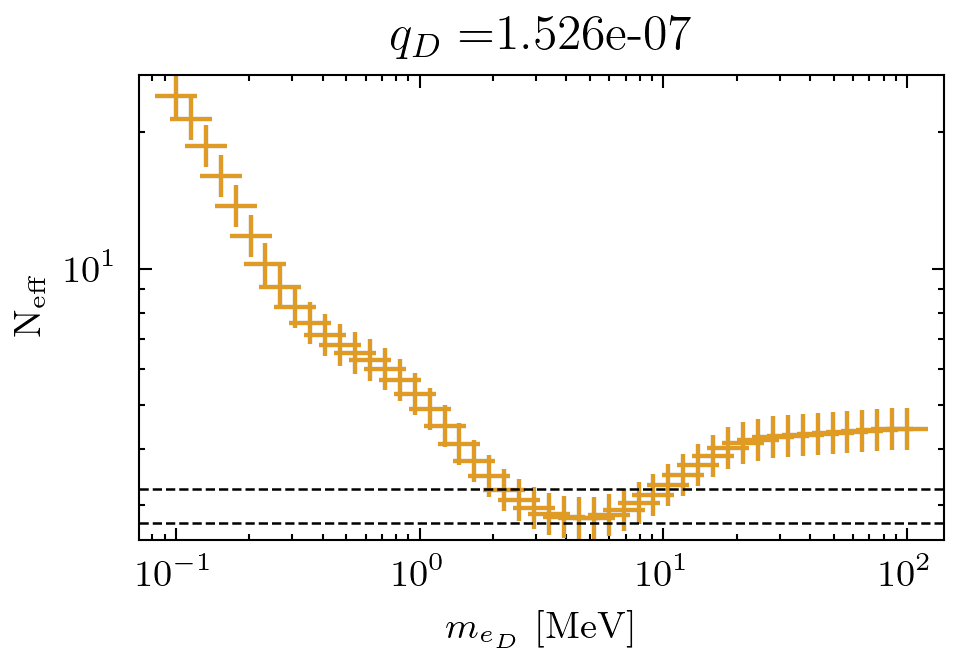

In [24]:
plt.plot(m_de[:, 0], N_eff[:, 0], linestyle='none', marker='+')
plt.plot(m_de[:, 1], N_eff[:, 1], linestyle='none', marker='+')
plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$m_{e_D}$ [MeV]')
plt.ylabel(r'N$_{\rm eff}$')

plt.title(r'$q_D = $' + f'{charges[0, 0]:.3e}')

plt.axhline(3.009 + 2*0.13, linestyle='dashed', color='black')
plt.axhline(3.009 - 2*0.13, linestyle='dashed', color='black')

plt.show()

In [30]:
N_eff[:, 0]

array([ 3.32016649,  4.31080185, 13.74507734, 10.26378353,  4.90204671,
        4.4177562 ,  5.67321346,  4.33104087,  4.00925703,  6.29006951,
        6.52058475,  2.93090579,  3.07887224,  2.80811237,  2.95675363,
        2.82568844, 11.81286547,  7.58896418,  3.48537497,  7.12744245,
        3.03179213,  3.68122424,  2.86214203,  4.29245615, 18.61888369,
        4.43041449, 24.10994386,  4.24084366,  4.19166489,  2.81897092,
        4.50077976, 21.36792044,  3.16152382,  4.10836793,  4.39856577,
        4.11245264,  3.50305811,  4.27041687,  3.86014025,  9.08769165,
        2.87001005,  4.35286145,  6.78436326,  6.01329248,  3.76267559,
        3.25217516, 16.03845857,  5.29601133,  4.37597555,  8.21958747])

In [31]:
N_eff[:, 0]

array([ 3.32016649,  4.31080185, 13.74507734, 10.26378353,  4.90204671,
        4.4177562 ,  5.67321346,  4.33104087,  4.00925703,  6.29006951,
        6.52058475,  2.93090579,  3.07887224,  2.80811237,  2.95675363,
        2.82568844, 11.81286547,  7.58896418,  3.48537497,  7.12744245,
        3.03179213,  3.68122424,  2.86214203,  4.29245615, 18.61888369,
        4.43041449, 24.10994386,  4.24084366,  4.19166489,  2.81897092,
        4.50077976, 21.36792044,  3.16152382,  4.10836793,  4.39856577,
        4.11245264,  3.50305811,  4.27041687,  3.86014025,  9.08769165,
        2.87001005,  4.35286145,  6.78436326,  6.01329248,  3.76267559,
        3.25217516, 16.03845857,  5.29601133,  4.37597555,  8.21958747])

In [27]:
(N_eff[:, 0] - N_eff[:, 1])/N_eff[:, 0]

array([ 0.00000000e+00,  0.00000000e+00,  4.19450779e-06, -1.06388760e-05,
        1.27704741e-05,  0.00000000e+00,  4.73024875e-06,  0.00000000e+00,
        0.00000000e+00,  2.82363614e-08,  1.25155625e-05,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        5.47809484e-06, -3.16112493e-05,  0.00000000e+00, -1.91546805e-05,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -1.10350557e-05,  0.00000000e+00, -2.44556226e-05,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -7.61266069e-06, -1.39538392e-05,
        0.00000000e+00,  6.38239332e-06,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  2.65536061e-05,
        0.00000000e+00,  0.00000000e+00, -2.71496571e-05, -1.95542779e-05,
        0.00000000e+00,  0.00000000e+00,  2.29680716e-05,  1.89903700e-05,
        0.00000000e+00,  8.24922944e-06])

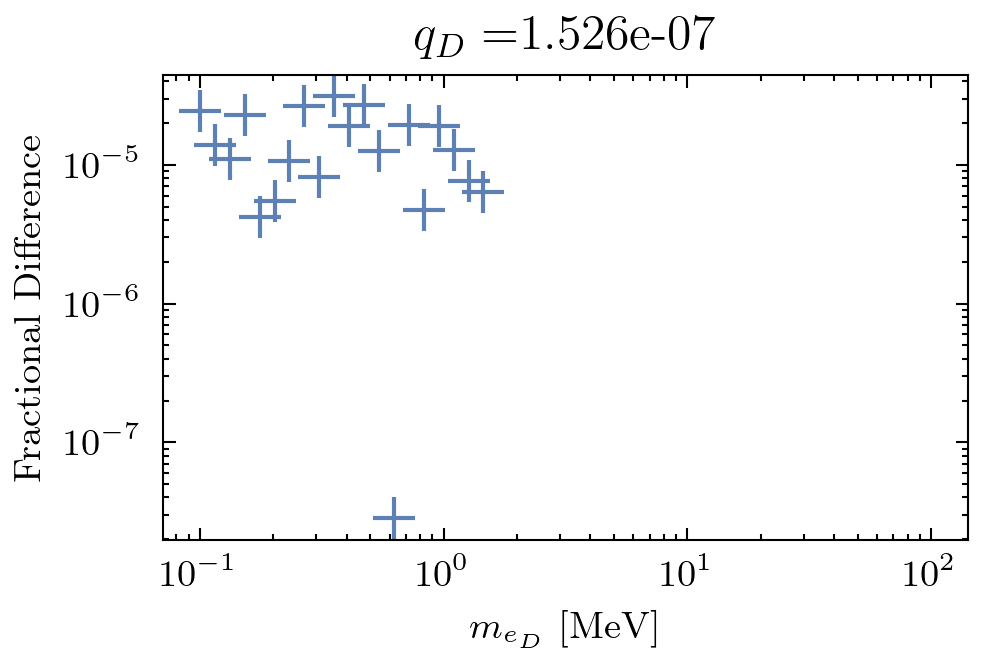

In [29]:
plt.plot(m_de[:, 0], np.abs((N_eff[:, 0] - N_eff[:, 1])/N_eff[:, 0]) , linestyle='none', marker='+')
plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$m_{e_D}$ [MeV]')
plt.ylabel(r'Fractional Difference')

plt.title(r'$q_D = $' + f'{charges[0, 0]:.3e}')


plt.show()